In [ ]:
  #Install packages
  !pip install lifelines #(untuk cox PH)
  !pip install scikit-survival #(Untuk Suevival Machine Learning)
  !pip install survshap #(untuk survSHAP(t))
  !pip install shap #untuk SHAP

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 349.3/349.3 kB 11.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 117.2/117.2 kB 11.5 MB/s eta 0:00:00
  Created wheel for autograd-gamma: filename=autograd_gamma-0.5.0-py3-none-any.whl size=4030 sha256=62673bff249fa7a1b107be4d18b5df43cc1510f25faa8bbb6578cb806eaebee9
  Stored in directory: /root/.cache/pip/wheels/8b/67/f4/2caaae2146198dcb824f31a303833b07b14a5ec863fb3acd7b
Successfully built autograd-gamma
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.9/48.9 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.9/3.9 MB 55.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 298.3/298.3 kB 22.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 220.1/220.1 kB 19.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 64.8 MB/s eta 0:00:00
  Attempting uninstall: osqp
    Found existing installation: osqp 1.0.4
    Uninstalling osqp-

In [ ]:
#run library needed
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from lifelines import KaplanMeierFitter, NelsonAalenFitter, CoxPHFitter
from lifelines.statistics import multivariate_logrank_test
from sklearn import set_config
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OrdinalEncoder
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sksurv.util import Surv
# import packages survshap(t) and RSF
from survshap import SurvivalModelExplainer, PredictSurvSHAP, ModelSurvSHAP
from sksurv.ensemble import RandomSurvivalForest # or any other survival model

#Set up data and EDA

In [ ]:
#import data
from google.colab import files
uploaded = files.upload()

Saving DataThesis.xlsx to DataThesis.xlsx


In [ ]:
df = pd.read_excel("/content/DataThesis.xlsx")
df.head()

,ID,Time,Status,X1,X2,X3,X4,X5,X6,X7,X8,X9,X10
0,2,228,0,Cemas,malas,TidakAdaGangguan,Female,20,Single,PerguruanTinggi,Fisik,TidakAda,Aktif
1,8,230,0,Cemas,malas,Masih,Female,58,Married,SD,Fisik,AdaRiwayat,Aktif
2,18,2,0,Cemas,malas,Masih,Female,50,Married,SMP,Fisik,TidakAda,Pasif
3,25,368,0,Cemas,malas,Masih,Female,33,Married,SD,Fisik,TidakAda,Aktif
4,26,7,0,Cemas,malas,Masih,Female,29,Married,PerguruanTinggi,Mental,AdaRiwayat,Aktif


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 97 entries, 0 to 96
Data columns (total 13 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   ID      97 non-null     int64 
 1   Time    97 non-null     int64 
 2   Status  97 non-null     int64 
 3   X1      97 non-null     object
 4   X2      97 non-null     object
 5   X3      97 non-null     object
 6   X4      97 non-null     object
 7   X5      97 non-null     int64 
 8   X6      97 non-null     object
 9   X7      97 non-null     object
 10  X8      97 non-null     object
 11  X9      97 non-null     object
 12  X10     97 non-null     object
dtypes: int64(4), object(9)
memory usage: 10.0+ KB


It can be seen that there is no missing values on the dataset, and the type of data is correct. <br>
However, ID is unimportant here, so it will delete from this analysis

In [ ]:
df.drop("ID", axis=1, inplace=True)

In [ ]:
df.describe(include='object')

,X1,X2,X3,X4,X6,X7,X8,X9,X10
count,97,97,97,97,97,97,97,97,97
unique,3,3,3,2,2,4,2,2,2
top,Cemas,malas,Pernah,Female,Married,SMA,Fisik,TidakAda,Aktif
freq,66,58,39,62,79,40,54,73,70


In [ ]:
df['X5'].describe()

,X5
count,97.000000
mean,42.412371
std,15.395990
min,19.000000
25%,29.000000
50%,41.000000
75%,54.000000
max,79.000000


<Axes: xlabel='X5'>

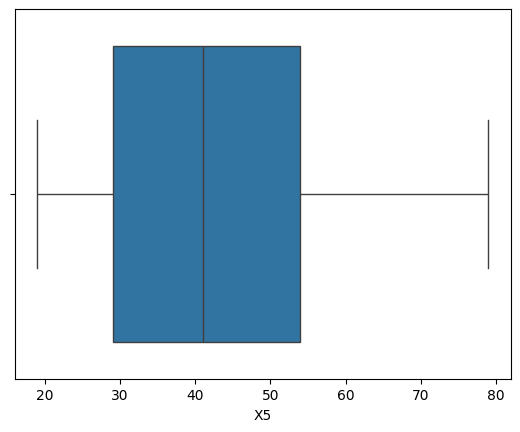

In [ ]:
sns.boxplot(x=df['X5'])

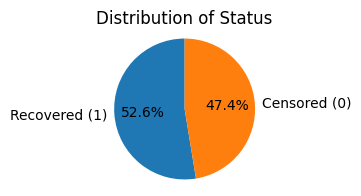

In [ ]:
# Count the occurrences of each status
status_counts = df['Status'].value_counts()
status_counts

# Create the pie chart
plt.figure(figsize=(2, 2))
plt.pie(status_counts, labels=['Recovered (1)', 'Censored (0)'], autopct='%1.1f%%', startangle=90)
plt.title('Distribution of Status')
plt.axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle.
plt.show()


it can be seen that many patients are recovery during the time of interest study even though the differences is not huge

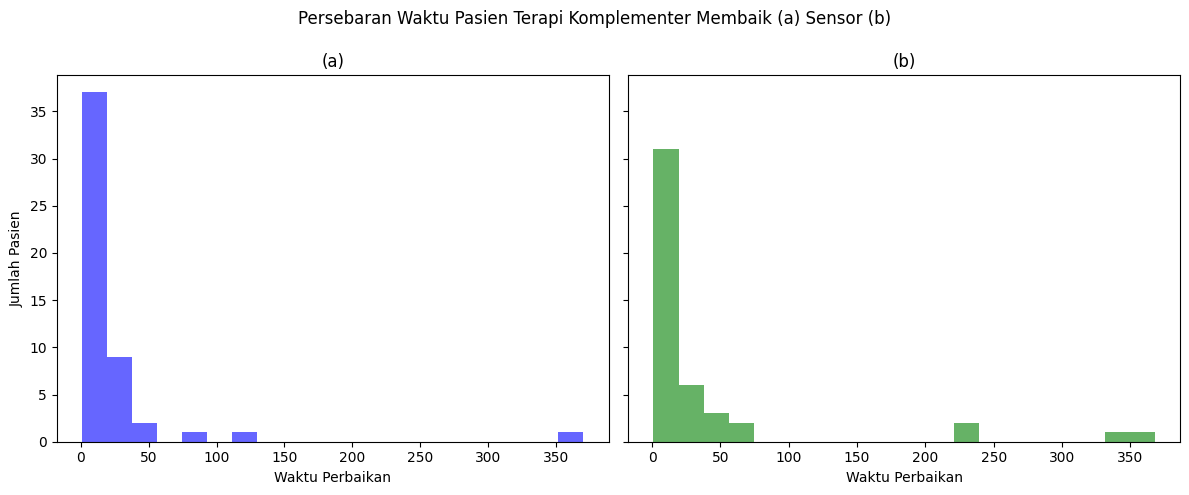

In [ ]:
# Pisahkan berdasarkan status
event_data = df[df['Status'] == 1]['Time']
censored_data = df[df['Status'] == 0]['Time']
import matplotlib.pyplot as plt

# Ukuran figure
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

# Histogram (a) - Pasien membaik
axes[0].hist(event_data, bins=20, color='blue', alpha=0.6)
axes[0].set_title('(a)')
axes[0].set_xlabel('Waktu Perbaikan')
axes[0].set_ylabel('Jumlah Pasien')

# Histogram (b) - Pasien censored
axes[1].hist(censored_data, bins=20, color='green', alpha=0.6)
axes[1].set_title('(b)')
axes[1].set_xlabel('Waktu Perbaikan')

# Judul utama
plt.suptitle('Persebaran Waktu Pasien Terapi Komplementer Membaik (a) Sensor (b)', fontsize=12)

plt.tight_layout()
plt.subplots_adjust(top=0.85)
plt.show()


Lama waktu yang dibutuhkan pasien-pasien terapi komplementer mengalami perubahan kondisi mental terjadi pada rentang waktu 1 sampai dengan 52 hari.

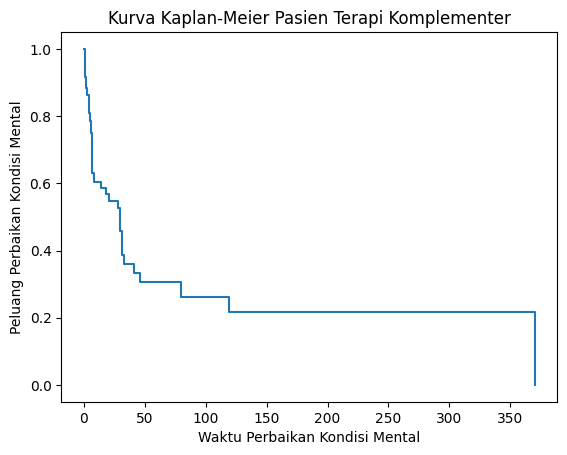

In [ ]:
# Kurva kaplan-meier tanpa confidence interval
from lifelines import KaplanMeierFitter
import matplotlib.pyplot as plt

# Membuat objek fitter
kmf = KaplanMeierFitter()
waktu_perbaikan = df['Time']
status = df['Status']

# Menghitung Kurva Kaplan-Meier
kmf.fit(waktu_perbaikan, event_observed=status)

# Plot Kurva Kaplan-Meier
plt.step(kmf.timeline, kmf.survival_function_, where='post')
plt.title('Kurva Kaplan-Meier Pasien Terapi Komplementer')
plt.xlabel('Waktu Perbaikan Kondisi Mental')
plt.ylabel('Peluang Perbaikan Kondisi Mental')
plt.show()

Kurva Kaplan-Meier menunjukkan bahwa sebagian besar pasien yang menjalani terapi komplementer mengalami perbaikan kondisi mental dalam waktu relatif singkat. Sekitar 50% pasien pulih dalam waktu kurang dari dua bulan. Namun, setelah fase awal tersebut, laju perbaikan melambat, dan terdapat sekitar 20% pasien yang tidak mengalami perbaikan kondisi mental hingga akhir masa observasi. Hal ini mengindikasikan bahwa terapi komplementer efektif untuk sebagian besar pasien, namun ada subkelompok yang mungkin membutuhkan pendekatan tambahan atau berbeda.

As we know that the most important assesment is the status in survival analysis.
To determine the status, in this analysis we need X1,X2 and X3 to asses whether patient recovery or not using complementary therapy, that's the reason I use Kaplan-Meier Curve here to determine is there any differences between three conditions based on S/G/R

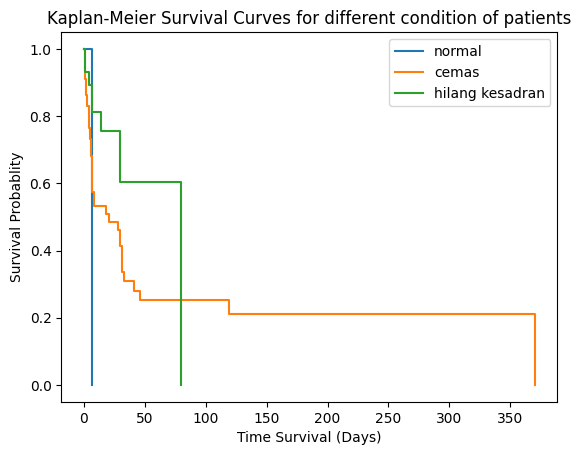

In [ ]:
#Kaplan Meier Curve for X1, X2, X3
time = df['Time']
event = df["Status"]

time = time.astype(float)
event = event.astype(int)

Sikap_normal = (df['X1'] == "Normal")
Sikap_cemas = (df['X1'] == "Cemas")
Sikap_hilang = (df['X1'] == "HilangKesadaran")


km = KaplanMeierFitter()
km.fit(time[Sikap_normal], event[Sikap_normal], label = 'normal')
ax1 = km.plot(ci_show = False)

km.fit(time[Sikap_cemas], event[Sikap_cemas], label = 'cemas')
km.plot(ax = ax1, ci_show = False)

km.fit(time[Sikap_hilang], event[Sikap_hilang], label = 'hilang kesadran')
km.plot(ax = ax1, ci_show = False)

plt.title('Kaplan-Meier Survival Curves for different condition of patients')
plt.xlabel('Time Survival (Days)')
plt.ylabel('Survival Probablity')
plt.show()

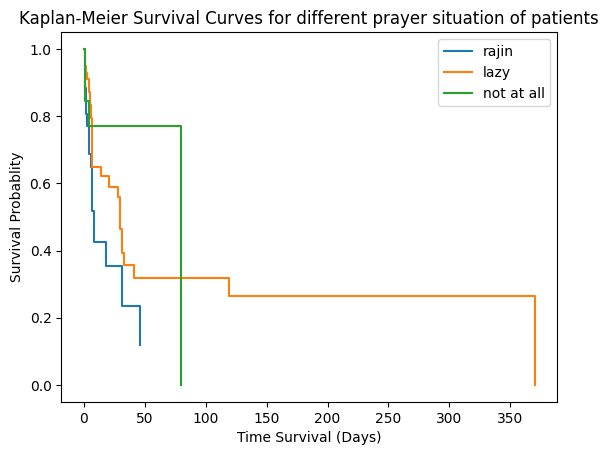

In [ ]:
#Kaplan Meier Curve for X1, X2, X3
time = df['Time']
event = df["Status"]

time = time.astype(float)
event = event.astype(int)

Sikap_rajin = (df['X2'] == "rajin")
Sikap_malas = (df['X2'] == "malas")
Sikap_tidaksholat = (df['X2'] == "TidakIbadah")


km = KaplanMeierFitter()
km.fit(time[Sikap_rajin], event[Sikap_rajin], label = 'rajin')
ax1 = km.plot(ci_show = False)

km.fit(time[Sikap_malas], event[Sikap_malas], label = 'lazy')
km.plot(ax = ax1, ci_show = False)

km.fit(time[Sikap_tidaksholat], event[Sikap_tidaksholat], label = 'not at all')
km.plot(ax = ax1, ci_show = False)

plt.title('Kaplan-Meier Survival Curves for different prayer situation of patients')
plt.xlabel('Time Survival (Days)')
plt.ylabel('Survival Probablity')
plt.show()

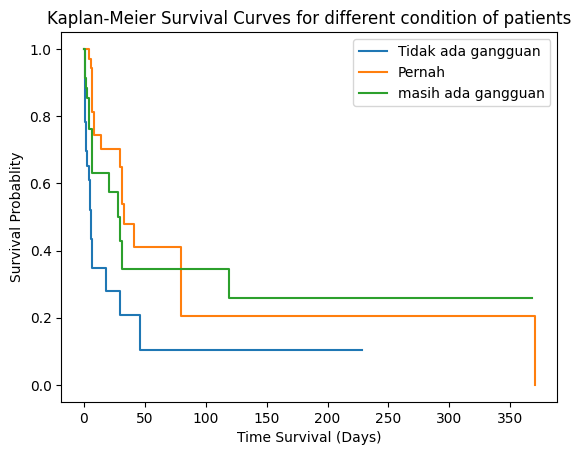

In [ ]:
#Kaplan Meier Curve for X3
time = df['Time']
event = df["Status"]

time = time.astype(float)
event = event.astype(int)

No_interaction = (df['X3'] == "TidakAdaGangguan")
Ever = (df['X3'] == "Pernah")
Still_has= (df['X3'] == "Masih")


km = KaplanMeierFitter()
km.fit(time[No_interaction], event[No_interaction], label = 'Tidak ada gangguan')
ax1 = km.plot(ci_show = False)

km.fit(time[Ever], event[Ever], label = 'Pernah')
km.plot(ax = ax1, ci_show = False)

km.fit(time[Still_has], event[Still_has], label = 'masih ada gangguan')
km.plot(ax = ax1, ci_show = False)

plt.title('Kaplan-Meier Survival Curves for different condition of patients')
plt.xlabel('Time Survival (Days)')
plt.ylabel('Survival Probablity')
plt.show()

Graph of the KM-curve for X1 depicts the differences of time to survive of those categories. It's clear that there are perpendiculars that is mean there are no significant different in three condition of patient's theraphy when they come to the hospital for the first time. However, this only descriptive analysis, we need to make sure from the statistics test of Log Rank test

In [ ]:
#Log Rank Test for X1, x2, x3 (multivariate log rank test)
kmf = KaplanMeierFitter()

#membuat dataframe baru khusus X1
import pandas as pd
data = pd.DataFrame({'durations': df['Time'],
                        'events': df['Status'],
                        'groups': df['X1']})
results = multivariate_logrank_test(data['durations'], data['groups'], data['events'])
print(results.summary)

   test_statistic         p  -log2(p)
0        5.428526  0.066254  3.915854


In [ ]:
#membuat dataframe baru khusus X2
import pandas as pd
data = pd.DataFrame({'durations': df['Time'],
                        'events': df['Status'],
                        'groups': df['X2']})
results = multivariate_logrank_test(data['durations'], data['groups'], data['events'])
print(results.summary)

   test_statistic         p  -log2(p)
0        5.613166  0.060411  4.049043


In [ ]:
#membuat dataframe baru khusus X3
import pandas as pd
data = pd.DataFrame({'durations': df['Time'],
                        'events': df['Status'],
                        'groups': df['X3']})
results = multivariate_logrank_test(data['durations'], data['groups'], data['events'])
print(results.summary)

   test_statistic         p  -log2(p)
0       13.082366  0.001443  9.436932


#Regresi Cox PH

In [ ]:
#import data
from google.colab import files
uploaded = files.upload()

Saving DataRegresi.xlsx to DataRegresi.xlsx


In [ ]:
df1 = pd.read_excel("/content/DataRegresi.xlsx")
df1.head()

,Time,Status,X1,X2,X3,X4,X5,X6,X7,X8,X9,X10,ID
0,1,1,1,1,0,1,24,1,2,0,0,1,1
1,228,0,1,1,0,1,20,0,3,0,0,1,2
2,1,1,1,0,0,1,54,1,2,1,1,1,3
3,46,0,2,0,1,1,56,1,0,0,0,1,4
4,8,0,2,2,1,1,34,1,3,0,1,1,5


In [ ]:
#Make dummy variables for each categorical variables, and drop first as a basis
data_encoded = pd.get_dummies(df1, columns=['X1', 'X2', 'X3', 'X4', 'X6', 'X7', 'X8', 'X9', 'X10'], drop_first=True)
data_encoded

,Time,Status,X5,ID,X1_1,X1_2,X2_1,X2_2,X3_1,X3_2,X4_1,X6_1,X7_1,X7_2,X7_3,X8_1,X9_1,X10_1
0,1,1,24,1,True,False,True,False,False,False,True,True,False,True,False,False,False,True
1,228,0,20,2,True,False,True,False,False,False,True,False,False,False,True,False,False,True
2,1,1,54,3,True,False,False,False,False,False,True,True,False,True,False,True,True,True
3,46,0,56,4,False,True,False,False,True,False,True,True,False,False,False,False,False,True
4,8,0,34,5,False,True,False,True,True,False,True,True,False,False,True,False,True,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
92,6,0,45,98,True,False,False,False,True,False,True,True,False,False,True,False,True,True
93,6,1,32,99,True,False,True,False,False,False,False,True,False,False,False,False,False,True
94,14,1,49,100,False,True,True,False,True,False,False,True,False,False,True,False,False,True
95,7,1,48,101,True,False,False,False,False,False,True,True,False,False,True,True,True,True


In [ ]:
Data_encoded = data_encoded.drop(['ID'], axis=1)
data_cph = Data_encoded
data_cph.head()

,Time,Status,X5,X1_1,X1_2,X2_1,X2_2,X3_1,X3_2,X4_1,X6_1,X7_1,X7_2,X7_3,X8_1,X9_1,X10_1
0,1,1,24,True,False,True,False,False,False,True,True,False,True,False,False,False,True
1,228,0,20,True,False,True,False,False,False,True,False,False,False,True,False,False,True
2,1,1,54,True,False,False,False,False,False,True,True,False,True,False,True,True,True
3,46,0,56,False,True,False,False,True,False,True,True,False,False,False,False,False,True
4,8,0,34,False,True,False,True,True,False,True,True,False,False,True,False,True,True


In [ ]:
Model_Cox = CoxPHFitter()
# Menyesuaikan model dengan data
Model_Cox.fit(data_cph, duration_col='Time', event_col='Status')
print(Model_Cox.print_summary())

/usr/local/lib/python3.11/dist-packages/lifelines/utils/__init__.py:1120: ConvergenceWarning: Column X7_1 have very low variance when conditioned on death event present or not. This may harm convergence. This could be a form of 'complete separation'. For example, try the following code:

>>> events = df['Status'].astype(bool)
>>> print(df.loc[events, 'X7_1'].var())
>>> print(df.loc[~events, 'X7_1'].var())

A very low variance means that the column X7_1 completely determines whether a subject dies or not. See https://stats.stackexchange.com/questions/11109/how-to-deal-with-perfect-separation-in-logistic-regression.

  warnings.warn(dedent(warning_text), ConvergenceWarning)
/usr/local/lib/python3.11/dist-packages/lifelines/fitters/coxph_fitter.py:1607: ConvergenceWarning: Newton-Raphson convergence completed successfully but norm(delta) is still high, 0.174. This may imply non-unique solutions to the maximum likelihood. Perhaps there is collinearity or complete separation in the dataset?

<lifelines.CoxPHFitter: fitted with 97 total observations, 46 right-censored observations>
             duration col = 'Time'
                event col = 'Status'
      baseline estimation = breslow
   number of observations = 97
number of events observed = 51
   partial log-likelihood = -177.06
         time fit was run = 2025-08-12 02:46:14 UTC

---
            coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                   
X5         -0.01      0.99      0.01           -0.03            0.02                0.97                1.02
X1_1       -0.08      0.92      0.87           -1.79            1.63                0.17                5.12
X1_2       -1.31      0.27      0.98           -3.22            0.60                0.04                1.83
X2_1       -0.52      0.59      0.41           -1.33            0.28                0.27                1.32
X2_2        0.06      1.06      0.65           -1.22            1.33                0.30                3.79
X3_1       -1.45      0.23      0.40           -2.24           -0.66                0.11                0.52
X3_2       -0.75      0.47      0.42           -1.56            0.07                0.21                1.07
X4_1       -0.36      0.70      0.35           -1.05            0.33                0.35                1.39
X6_1       -0.38      0.69      0.46           -1.28            0.53                0.28                1.69
X7_1      -15.44      0.00   2997.03        -5889.51         5858.64                0.00                 inf
X7_2        0.24      1.27      0.39           -0.52            0.99                0.60                2.70
X7_3       -0.71      0.49      0.49           -1.66            0.25                0.19                1.28
X8_1       -0.37      0.69      0.38           -1.10            0.37                0.33                1.44
X9_1       -0.40      0.67      0.38           -1.14            0.34                0.32                1.40
X10_1      -0.43      0.65      0.39           -1.20            0.34                0.30                1.40

           cmp to     z      p  -log2(p)
covariate                               
X5           0.00 -0.37   0.71      0.49
X1_1         0.00 -0.09   0.93      0.11
X1_2         0.00 -1.34   0.18      2.48
X2_1         0.00 -1.28   0.20      2.32
X2_2         0.00  0.09   0.93      0.11
X3_1         0.00 -3.59 <0.005     11.58
X3_2         0.00 -1.80   0.07      3.80
X4_1         0.00 -1.02   0.31      1.70
X6_1         0.00 -0.82   0.41      1.27
X7_1         0.00 -0.01   1.00      0.01
X7_2         0.00  0.62   0.54      0.90
X7_3         0.00 -1.45   0.15      2.77
X8_1         0.00 -0.98   0.33      1.61
X9_1         0.00 -1.07   0.29      1.81
X10_1        0.00 -1.10   0.27      1.89
---
Concordance = 0.76
Partial AIC = 384.12
log-likelihood ratio test = 30.87 on 15 df
-log2(p) of ll-ratio test = 6.77

None


In [ ]:
# Uji signifikansi model secara keseluruhan (uji serentak)
Model_Cox = CoxPHFitter()
Model_Cox.fit(data_cph, duration_col='Time', event_col='Status')

# Cetak ringkasan statistik uji serentak
print(Model_Cox.log_likelihood_ratio_test())


<lifelines.StatisticalResult: log-likelihood ratio test>
null_distribution = chi squared
  degrees_freedom = 15
        test_name = log-likelihood ratio test

---
 test_statistic    p  -log2(p)
          30.87 0.01      6.77


/usr/local/lib/python3.11/dist-packages/lifelines/utils/__init__.py:1120: ConvergenceWarning: Column X7_1 have very low variance when conditioned on death event present or not. This may harm convergence. This could be a form of 'complete separation'. For example, try the following code:

>>> events = df['Status'].astype(bool)
>>> print(df.loc[events, 'X7_1'].var())
>>> print(df.loc[~events, 'X7_1'].var())

A very low variance means that the column X7_1 completely determines whether a subject dies or not. See https://stats.stackexchange.com/questions/11109/how-to-deal-with-perfect-separation-in-logistic-regression.

  warnings.warn(dedent(warning_text), ConvergenceWarning)
/usr/local/lib/python3.11/dist-packages/lifelines/fitters/coxph_fitter.py:1607: ConvergenceWarning: Newton-Raphson convergence completed successfully but norm(delta) is still high, 0.174. This may imply non-unique solutions to the maximum likelihood. Perhaps there is collinearity or complete separation in the dataset?

In [ ]:
# The following code exports the summary to an excel file.
#from google.colab import files
# Access the summary as a pandas DataFrame
#summary_df = Model_Cox.summary
# Export to Excel file.
#summary_df.to_excel('cox_ph_summary.xlsx', index=False)
# Download the file.
#files.download('cox_ph_summary.xlsx')

In [ ]:
from lifelines.statistics import proportional_hazard_test # Import the missing function

#Model_Cox = CoxPHFitter()
# Menyesuaikan model dengan data
#Model_Cox.fit(data_cph, duration_col='Time', event_col='Status')

scaled_schoenfeld = Model_Cox.compute_residuals(training_dataframe=data_cph, kind='scaled_schoenfeld')
proportional_hazard_test(fitted_cox_model=Model_Cox,
                         training_df=data_cph,
                         time_transform='log',
                         precomputed_residuals=scaled_schoenfeld)

<lifelines.StatisticalResult: proportional_hazard_test>
    time_transform = log
 null_distribution = chi squared
degrees_of_freedom = 1
             model = <lifelines.CoxPHFitter: fitted with 97 total observations, 46 right-censored observations>
         test_name = proportional_hazard_test

---
       test_statistic    p  -log2(p)
X10_1            2.90 0.09      3.49
X1_1             0.60 0.44      1.19
X1_2             0.23 0.63      0.67
X2_1             2.73 0.10      3.35
X2_2             1.20 0.27      1.87
X3_1             6.96 0.01      6.90
X3_2             0.39 0.53      0.92
X4_1             0.31 0.58      0.79
X5               1.18 0.28      1.86
X6_1             0.11 0.74      0.43
X7_1             0.00 1.00      0.00
X7_2             0.51 0.47      1.07
X7_3             1.50 0.22      2.18
X8_1             0.72 0.40      1.33
X9_1             0.76 0.38      1.39

In [ ]:
# The following code exports the summary to an excel file.
#from google.colab import files
# Access the summary as a pandas DataFrame
#summary_df = Model_Cox.summary
# Export to Excel file.
#summary_df.to_excel('cox_ph_summary.xlsx', index=False)
# Download the file.
#files.download('cox_ph_summary.xlsx')

#Random Survival Forest

In [ ]:
# Attention: duration column must be index 0, event column index 1 in y
y_surv = Surv.from_arrays(event=data_cph["Status"].astype(bool), time=data_cph["Time"])
X = data_cph.drop(["Status", "Time"], axis=1)

random_state = 42
X_train, X_test, y_train, y_test = train_test_split(X, y_surv, test_size=0.33, random_state=random_state)

In [ ]:
# prepare survival model
model = RandomSurvivalForest(
    max_depth=5,
    n_estimators=1000,      # Jumlah trees
    min_samples_split=6,  # Minimum sample untuk split
    min_samples_leaf=3,    # Minimum sample di daun
    max_features="sqrt",   # Fitur maksimum untuk split
    random_state=42,
    #verbose=1,
    #n_jobs=-1,


    #Reproducibility
)
model.fit(X, y_surv)

RandomSurvivalForest(max_depth=5, n_estimators=1000, random_state=42)

In [ ]:
# Prediksi menggunakan model RSF
preds = model.predict(X_test)
preds

array([21.36335452,  9.29700033, 16.99973672,  3.71114649, 11.79665986,
       13.17638022, 13.96832491,  7.77347929, 13.93732103, 18.57829505,
        9.35490698,  6.69851653,  9.9274431 , 14.25831407, 18.13888804,
        5.82176052, 18.96614765, 14.23004557, 10.08920923, 10.92923305,
       12.96699862,  9.09898348,  5.53908514,  5.50217477, 13.13122046,
       21.29824336,  6.68059718, 10.30647638, 10.69134393, 16.20099998,
       16.95619963, 10.86822068,  8.11700983])

In [ ]:
# Prediksi menggunakan model RSF
preds_train = model.predict(X_train)
preds_train

array([12.80976557, 17.4348652 , 10.94948712, 11.87128378, 20.47821206,
        8.29265409,  8.24264251, 11.38350632,  9.38857569, 15.13695958,
        9.30518325,  6.34371685,  5.84198001,  7.83442935,  9.33108344,
       17.36935906,  7.51349486,  4.39335219, 15.46591297,  5.22579278,
       17.95223009,  4.79190462, 13.84122006,  5.67236905,  9.52330908,
       15.5782481 , 13.77767486, 15.19192485, 11.04732525, 12.1161354 ,
        7.68577492, 12.18431926, 15.13698515, 13.05152271, 12.5817459 ,
        9.07905659, 11.07754707, 14.06998461, 13.34242644, 11.47953933,
       21.35889078, 16.27376282, 16.98712861, 20.72466634, 14.36509604,
        7.55112512, 17.07994201,  9.63246714, 13.05300975, 13.9302083 ,
       14.22022324,  6.44190868, 19.47176062, 13.12357657, 19.3019715 ,
       13.40120824, 13.68829696,  8.33750768, 11.48204778,  5.45792372,
       16.937563  ,  6.74405687, 11.64124171, 17.61842436])

In [ ]:
pd.Series(model.predict(X_test))

,0
0,21.363355
1,9.297000
2,16.999737
3,3.711146
4,11.796660
5,13.176380
6,13.968325
7,7.773479
8,13.937321
9,18.578295


##visualisasi hasil RSF

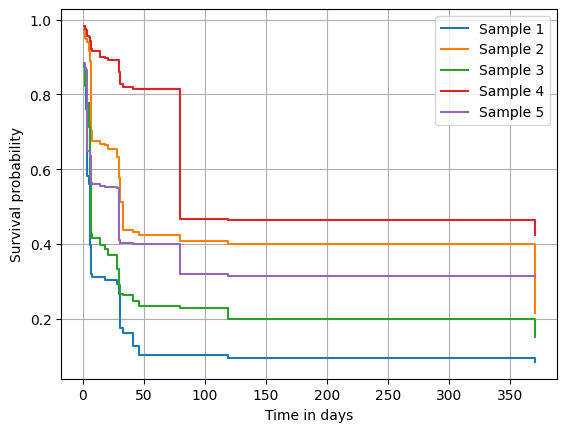

In [ ]:
surv = model.predict_survival_function(X_test, return_array=True)

for i, s in enumerate(surv[:5]):
    plt.step(model.unique_times_, s, where="post", label=f"Sample {i+1}")
plt.ylabel("Survival probability")
plt.xlabel("Time in days")
plt.legend()
plt.grid(True)

In [ ]:
first_5_patients = X_test.iloc[:5]
print(first_5_patients)

    X5   X1_1   X1_2   X2_1   X2_2   X3_1   X3_2   X4_1   X6_1   X7_1   X7_2  \
62  25   True  False   True  False  False  False  False   True  False   True   
40  53   True  False   True  False   True  False   True   True  False  False   
93  32   True  False   True  False  False  False  False   True  False  False   
18  62  False   True  False   True   True  False   True   True  False   True   
81  24  False   True  False   True  False   True  False  False  False   True   

     X7_3   X8_1   X9_1  X10_1  
62  False   True  False  False  
40  False   True  False   True  
93  False  False  False   True  
18  False  False  False   True  
81  False  False  False   True  


In [ ]:
#chf = model.predict_cumulative_hazard_function(X_test, return_array=True)

## evaluasi c index

In [ ]:
c_index_train = model.score(X_train, y_train)
f"{c_index_train:.5f}"

'0.87105'

In [ ]:
c_index_testing = model.score(X_test, y_test)
f"{c_index_testing:.5f}"

'0.84000'

##Feature Selection

In [ ]:
from sksurv.metrics import concordance_index_censored

def custom_c_index(model, X, y):
    pred = model.predict(X)
    result = concordance_index_censored(
        y["event"], y["time"], pred
    )
    return result[0]  # hanya ambil nilai C-index (bukan tuple lengkap)


In [ ]:
from sklearn.inspection import permutation_importance

result = permutation_importance(model, X_test, y_test, n_repeats=15, random_state=random_state, scoring=custom_c_index)

In [ ]:
pd.DataFrame(
    {
        k: result[k]
        for k in (
            "importances_mean",
            "importances_std",
        )
    },
    index=X_test.columns,
).sort_values(by="importances_mean", ascending=False)

,importances_mean,importances_std
X3_1,0.082462,0.031862
X5,0.059282,0.015218
X10_1,0.041436,0.026178
X3_2,0.030154,0.011578
X4_1,0.026051,0.016354
X9_1,0.019077,0.009743
X8_1,0.018667,0.012229
X2_1,0.010462,0.020029
X7_3,0.009436,0.006596
X6_1,0.002051,0.003838


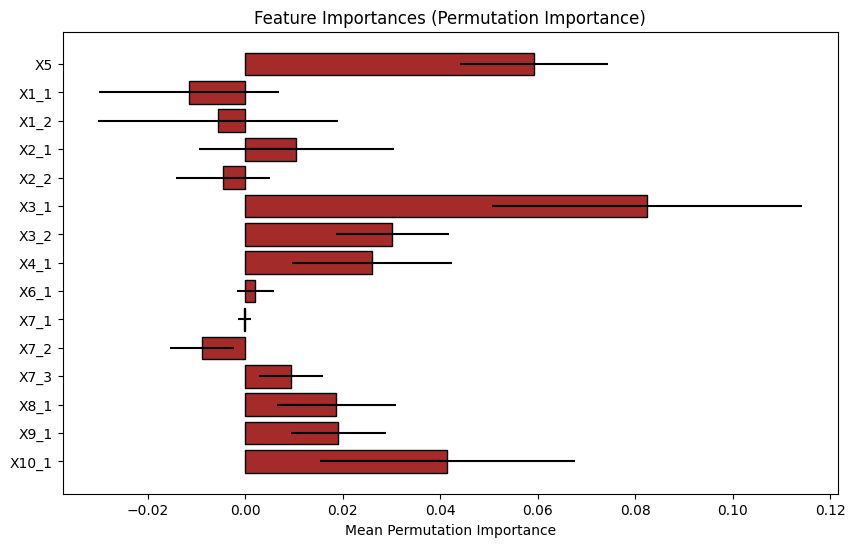

In [ ]:
features = X.columns
importances = result.importances_mean
stds = result.importances_std
# Plot importance mean dengan standar deviasi
plt.figure(figsize=(10, 6))
plt.barh(features, importances, xerr=stds, color='brown', edgecolor='black')
plt.xlabel("Mean Permutation Importance")
plt.title("Feature Importances (Permutation Importance)")
plt.gca().invert_yaxis()
plt.show()


#RSF model setelah seleksi fitur

In [ ]:
DF = pd.read_excel("/content/DataRegresi.xlsx")
DF.head()

,Time,Status,X1,X2,X3,X4,X5,X6,X7,X8,X9,X10,ID
0,1,1,1,1,0,1,24,1,2,0,0,1,1
1,228,0,1,1,0,1,20,0,3,0,0,1,2
2,1,1,1,0,0,1,54,1,2,1,1,1,3
3,46,0,2,0,1,1,56,1,0,0,0,1,4
4,8,0,2,2,1,1,34,1,3,0,1,1,5


In [ ]:
# Drop columns x1, x2, and x7 from data_cph
data2 = DF.drop(['ID','X1', 'X2','X7'], axis=1)
data2

,Time,Status,X3,X4,X5,X6,X8,X9,X10
0,1,1,0,1,24,1,0,0,1
1,228,0,0,1,20,0,0,0,1
2,1,1,0,1,54,1,1,1,1
3,46,0,1,1,56,1,0,0,1
4,8,0,1,1,34,1,0,1,1
...,...,...,...,...,...,...,...,...,...
92,6,0,1,1,45,1,0,1,1
93,6,1,0,0,32,1,0,0,1
94,14,1,1,0,49,1,0,0,1
95,7,1,0,1,48,1,1,1,1


In [ ]:
Encode_data = pd.get_dummies(data2, columns=[ 'X3', 'X4', 'X6','X8', 'X9', 'X10'], drop_first=True)
Encode_data

,Time,Status,X5,X3_1,X3_2,X4_1,X6_1,X8_1,X9_1,X10_1
0,1,1,24,False,False,True,True,False,False,True
1,228,0,20,False,False,True,False,False,False,True
2,1,1,54,False,False,True,True,True,True,True
3,46,0,56,True,False,True,True,False,False,True
4,8,0,34,True,False,True,True,False,True,True
...,...,...,...,...,...,...,...,...,...,...
92,6,0,45,True,False,True,True,False,True,True
93,6,1,32,False,False,False,True,False,False,True
94,14,1,49,True,False,False,True,False,False,True
95,7,1,48,False,False,True,True,True,True,True


In [ ]:
# Attention: duration column must be index 0, event column index 1 in y
y_surv = Surv.from_arrays(event=Encode_data["Status"].astype(bool), time=Encode_data["Time"])
X = Encode_data.drop(["Status", "Time"], axis=1)

random_state = 42
X_train, X_test, y_train, y_test = train_test_split(X, y_surv, test_size=0.33, random_state=random_state)

In [ ]:
# prepare survival model
model2 = RandomSurvivalForest(
    max_depth=5,
    n_estimators=1000,      # Jumlah trees
    min_samples_split=6,  # Minimum sample untuk split
    min_samples_leaf=3,    # Minimum sample di daun
    max_features="sqrt",   # Fitur maksimum untuk split
    random_state=42,
    #verbose=1,
    #n_jobs=-1,


    #Reproducibility
)
model2.fit(X, y_surv)

RandomSurvivalForest(max_depth=5, n_estimators=1000, random_state=42)

In [ ]:
# Prediksi menggunakan model RSF
preds = model2.predict(X_test)
preds

array([20.42258962,  9.31507455, 16.98329787,  5.85876492, 15.60949334,
        8.38237212, 11.68683558,  7.18810533, 12.49273465, 17.17334451,
        6.3943066 ,  9.22274451, 11.58381138, 12.55042999, 17.23173802,
        6.74246128, 19.2288032 , 18.11067068,  8.39593148, 17.67350848,
       19.12761621,  7.07424238, 11.89383134,  7.31126827, 13.53724686,
       21.02945803, 10.47544168, 11.44070035, 14.24545266, 15.02460649,
       15.12956924,  7.776986  , 10.68820157])

In [ ]:
pd.Series(model2.predict(X_test))

,0
0,20.422590
1,9.315075
2,16.983298
3,5.858765
4,15.609493
5,8.382372
6,11.686836
7,7.188105
8,12.492735
9,17.173345


In [ ]:
result = permutation_importance(model2, X_test, y_test, n_repeats=15, random_state=random_state, scoring = custom_c_index)
pd.DataFrame(
    {
        k: result[k]
        for k in (
            "importances_mean",
            "importances_std",
        )
    },
    index=X_test.columns,
).sort_values(by="importances_mean", ascending=False)

,importances_mean,importances_std
X5,0.110462,0.025646
X3_1,0.101538,0.043092
X10_1,0.066667,0.026341
X3_2,0.045949,0.013551
X8_1,0.043487,0.017901
X4_1,0.032000,0.021664
X9_1,0.025846,0.019126
X6_1,0.004513,0.010289


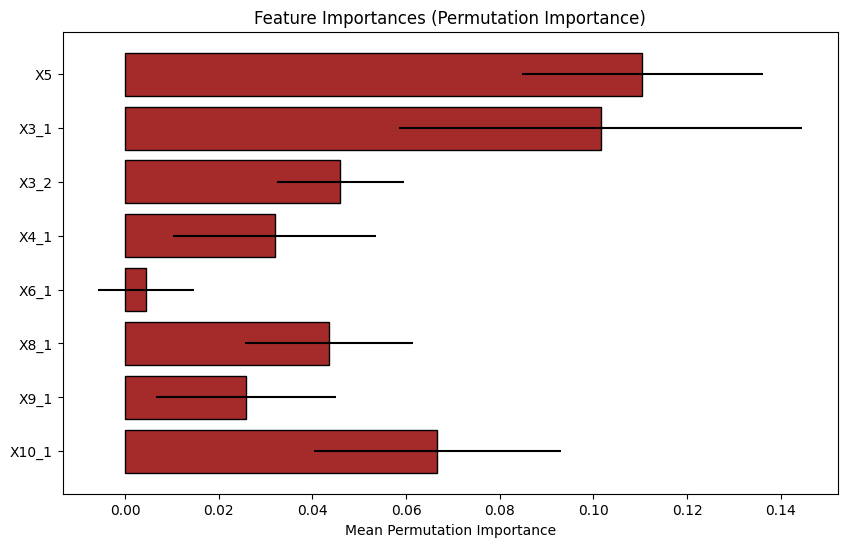

In [ ]:
features = X.columns
importances = result.importances_mean
stds = result.importances_std
# Plot importance mean dengan standar deviasi
plt.figure(figsize=(10, 6))
plt.barh(features, importances, xerr=stds, color='brown', edgecolor='black')
plt.xlabel("Mean Permutation Importance")
plt.title("Feature Importances (Permutation Importance)")
plt.gca().invert_yaxis()
plt.show()


In [ ]:
c_index_testing = model2.score(X_test, y_test)
f"{c_index_testing:.5f}"

'0.91077'

In [ ]:
c_index_train = model2.score(X_train, y_train)
f"{c_index_train:.5f}"

'0.80702'

#SurvSHAP(t)

In [ ]:
from survshap import SurvivalModelExplainer, PredictSurvSHAP, ModelSurvSHAP

In [ ]:
explainer = SurvivalModelExplainer(model=model2, data=X, y=y_surv)

In [ ]:
# compute SHAP values for a single instance
observation_A = X.iloc[[96]]
survshap_A = PredictSurvSHAP()
survshap_A.fit(explainer = explainer, new_observation = observation_A)

In [ ]:
survshap_A.result.to_excel('survshapresultpasien97.xlsx', index=False)

In [ ]:
survshap_A.plot()